In [2]:
import pandas as pd

In [12]:
from google.colab import files

uploaded = files.upload()

Saving Ecommerce delivery logistics.xlsx to Ecommerce delivery logistics (1).xlsx


In [14]:
from google.colab import files

uploaded = files.upload()

print(uploaded.keys())

Saving Ecommerce delivery logistics.xlsx to Ecommerce delivery logistics (2).xlsx
dict_keys(['Ecommerce delivery logistics (2).xlsx'])


In [15]:
import pandas as pd

df = pd.read_excel("Ecommerce delivery logistics (2).xlsx")

print(df.head())

   Order_ID  Order_Date  Warehouse Product_Category Shipping_Mode  \
0  ORD10002       46174  Bengaluru          Grocery       Express   
1  ORD10003       46192  Hyderabad      Electronics       Express   
2  ORD10004       46111    Chennai          Grocery      Standard   
3  ORD10005       46103      Kochi           Beauty      Standard   
4  ORD10006       46104  Bengaluru   Home & Kitchen      Standard   

   Distance_km  Promised_Days  Actual_Delivery_Days  Delay_Days  \
0        126.6              2                     3           1   
1        321.1              3                     7           4   
2        324.9              3                     5           2   
3        144.0              3                     4           1   
4        146.2              5                     7           2   

   Order_Value_INR Delivery_Status  Customer_Rating  
0          1500.00         Delayed              5.0  
1          1500.00         Delayed              3.0  
2          1500.00  

In [16]:
print(df.isnull().sum())

Order_ID                0
Order_Date              0
Warehouse               0
Product_Category        0
Shipping_Mode           0
Distance_km             2
Promised_Days           0
Actual_Delivery_Days    0
Delay_Days              0
Order_Value_INR         0
Delivery_Status         0
Customer_Rating         3
dtype: int64


In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [18]:
print(df.dtypes)

Order_ID                 object
Order_Date                int64
Warehouse                object
Product_Category         object
Shipping_Mode            object
Distance_km             float64
Promised_Days             int64
Actual_Delivery_Days      int64
Delay_Days                int64
Order_Value_INR         float64
Delivery_Status          object
Customer_Rating         float64
dtype: object


In [21]:
print(df.describe())

         Order_Date  Distance_km  Promised_Days  Actual_Delivery_Days  \
count    200.000000   198.000000     200.000000            200.000000   
mean   46119.380000   177.317677       3.290000              4.615000   
std       51.336173   124.996986       1.583806              2.114029   
min    46023.000000    23.300000       1.000000              1.000000   
25%    46082.000000    96.075000       2.000000              3.000000   
50%    46123.500000   156.300000       3.000000              4.000000   
75%    46168.250000   227.125000       5.000000              6.000000   
max    46203.000000  1200.000000       6.000000             10.000000   

       Delay_Days  Order_Value_INR  Customer_Rating  
count  200.000000        200.00000       197.000000  
mean     1.325000       1246.07510         4.319289  
std      1.116066        339.92667         0.640259  
min      0.000000        336.97000         2.200000  
25%      0.000000       1033.24500         3.800000  
50%      1.000000 

In [22]:
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    origin="1899-12-30",
    unit="D"
)

print(df[["Order_Date"]].head())
print(df["Order_Date"].dtype)

  Order_Date
0 2026-06-01
1 2026-06-19
2 2026-03-30
3 2026-03-22
4 2026-03-23
datetime64[ns]


In [23]:
df["Distance_km"] = df["Distance_km"].fillna(df["Distance_km"].median())

print(df.isnull().sum())

Order_ID                0
Order_Date              0
Warehouse               0
Product_Category        0
Shipping_Mode           0
Distance_km             0
Promised_Days           0
Actual_Delivery_Days    0
Delay_Days              0
Order_Value_INR         0
Delivery_Status         0
Customer_Rating         3
dtype: int64


In [24]:
X = df.drop(columns=[
    "Order_ID",
    "Actual_Delivery_Days",
    "Delay_Days",
    "Delivery_Status",
    "Customer_Rating"
])

y = df["Actual_Delivery_Days"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Order_Date', 'Warehouse', 'Product_Category', 'Shipping_Mode', 'Distance_km', 'Promised_Days', 'Order_Value_INR']

Target:
Actual_Delivery_Days


In [25]:
X["Order_Year"] = X["Order_Date"].dt.year
X["Order_Month"] = X["Order_Date"].dt.month
X["Order_DayOfWeek"] = X["Order_Date"].dt.dayofweek

X = X.drop(columns=["Order_Date"])

print(X.head())
print("\nFeatures:")
print(X.columns.tolist())

   Warehouse Product_Category Shipping_Mode  Distance_km  Promised_Days  \
0  Bengaluru          Grocery       Express        126.6              2   
1  Hyderabad      Electronics       Express        321.1              3   
2    Chennai          Grocery      Standard        324.9              3   
3      Kochi           Beauty      Standard        144.0              3   
4  Bengaluru   Home & Kitchen      Standard        146.2              5   

   Order_Value_INR  Order_Year  Order_Month  Order_DayOfWeek  
0          1500.00        2026            6                0  
1          1500.00        2026            6                4  
2          1500.00        2026            3                0  
3          1332.56        2026            3                6  
4          1500.00        2026            3                0  

Features:
['Warehouse', 'Product_Category', 'Shipping_Mode', 'Distance_km', 'Promised_Days', 'Order_Value_INR', 'Order_Year', 'Order_Month', 'Order_DayOfWeek']


In [26]:
X = pd.get_dummies(
    X,
    columns=["Warehouse", "Product_Category", "Shipping_Mode"],
    drop_first=True
)

print(X.head())
print("\nShape of X:", X.shape)

   Distance_km  Promised_Days  Order_Value_INR  Order_Year  Order_Month  \
0        126.6              2          1500.00        2026            6   
1        321.1              3          1500.00        2026            6   
2        324.9              3          1500.00        2026            3   
3        144.0              3          1332.56        2026            3   
4        146.2              5          1500.00        2026            3   

   Order_DayOfWeek  Warehouse_Chennai  Warehouse_Coimbatore  \
0                0              False                 False   
1                4              False                 False   
2                0               True                 False   
3                6              False                 False   
4                0              False                 False   

   Warehouse_Hyderabad  Warehouse_Kochi  Product_Category_Electronics  \
0                False            False                         False   
1                 True  

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 16)
Testing data: (40, 16)


In [28]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Linear Regression model trained successfully!")
print("First 5 predictions:", y_pred_lr[:5])

Linear Regression model trained successfully!
First 5 predictions: [6.66376642 3.7589998  5.94939038 2.88405931 1.20376831]


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(mae_lr, 3))
print("RMSE:", round(rmse_lr, 3))
print("R²  :", round(r2_lr, 3))

Linear Regression Results
-------------------------
MAE : 0.848
RMSE: 1.042
R²  : 0.74


In [30]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

print("Decision Tree model trained successfully!")
print("First 5 predictions:", y_pred_dt[:5])

Decision Tree model trained successfully!
First 5 predictions: [6.8125     4.06666667 4.76923077 2.44444444 3.        ]


In [31]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("--------------------")
print("MAE :", round(mae_dt, 3))
print("RMSE:", round(rmse_dt, 3))
print("R²  :", round(r2_dt, 3))

Decision Tree Results
--------------------
MAE : 0.921
RMSE: 1.202
R²  : 0.654


In [32]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=5
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [33]:
# Evaluate Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# Model comparison
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [mae_lr, mae_dt, mae_rf],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf],
    "R2": [r2_lr, r2_dt, r2_rf]
})

print(results.round(3))

               Model    MAE   RMSE     R2
0  Linear Regression  0.848  1.042  0.740
1      Decision Tree  0.921  1.202  0.654
2      Random Forest  0.894  1.101  0.710


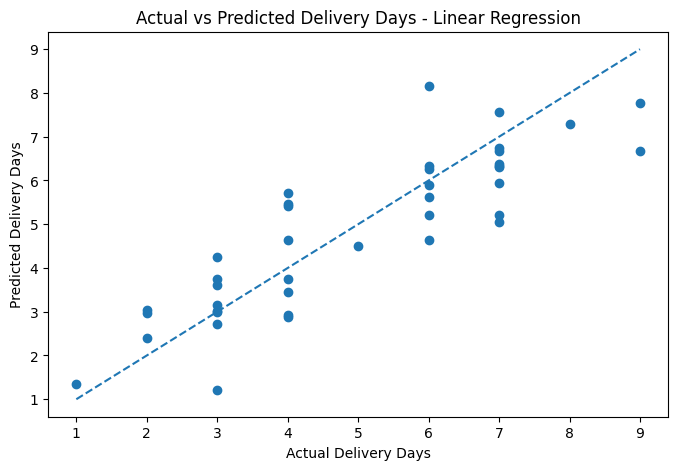

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Delivery Days")
plt.ylabel("Predicted Delivery Days")
plt.title("Actual vs Predicted Delivery Days - Linear Regression")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [35]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation for Linear Regression
cv_scores = cross_val_score(
    model_lr,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

cv_mae = -cv_scores.mean()

print("5-Fold Cross-Validation MAE:", round(cv_mae, 3))

5-Fold Cross-Validation MAE: 0.877


In [36]:
# Logistics Optimization: Identify orders that may need priority

optimization_df = df.loc[y_test.index, [
    "Order_ID",
    "Warehouse",
    "Shipping_Mode",
    "Distance_km",
    "Promised_Days"
]].copy()

optimization_df["Predicted_Delivery_Days"] = y_pred_lr

optimization_df["Predicted_Delay_Days"] = (
    optimization_df["Predicted_Delivery_Days"]
    - optimization_df["Promised_Days"]
).clip(lower=0)

optimization_df["Priority"] = optimization_df["Predicted_Delay_Days"].apply(
    lambda x: "High" if x > 1 else ("Medium" if x > 0 else "Normal")
)

optimization_df = optimization_df.sort_values(
    "Predicted_Delay_Days",
    ascending=False
)

print(optimization_df.head(10))# Logistics Optimization: Identify orders that may need priority

optimization_df = df.loc[y_test.index, [
    "Order_ID",
    "Warehouse",
    "Shipping_Mode",
    "Distance_km",
    "Promised_Days"
]].copy()

optimization_df["Predicted_Delivery_Days"] = y_pred_lr

optimization_df["Predicted_Delay_Days"] = (
    optimization_df["Predicted_Delivery_Days"]
    - optimization_df["Promised_Days"]
).clip(lower=0)

optimization_df["Priority"] = optimization_df["Predicted_Delay_Days"].apply(
    lambda x: "High" if x > 1 else ("Medium" if x > 0 else "Normal")
)

optimization_df = optimization_df.sort_values(
    "Predicted_Delay_Days",
    ascending=False
)

print(optimization_df.head(10))

     Order_ID  Warehouse Shipping_Mode  Distance_km  Promised_Days  \
65   ORD10067  Hyderabad      Standard        450.0              5   
84   ORD10086  Hyderabad       Express        437.9              2   
177  ORD10179      Kochi      Standard        193.6              4   
186  ORD10188  Hyderabad      Standard        220.6              6   
30   ORD10032  Hyderabad      Standard        218.8              4   
75   ORD10077  Hyderabad      Standard        140.9              6   
165  ORD10167    Chennai      Standard        253.0              5   
104  ORD10106  Hyderabad       Express        269.5              2   
150  ORD10152  Hyderabad      Standard        161.6              4   
174  ORD10176      Kochi      Standard        183.6              5   

     Predicted_Delivery_Days  Predicted_Delay_Days Priority  
65                  7.557944              2.557944     High  
84                  4.503835              2.503835     High  
177                 6.340918              2

In [37]:
priority_summary = optimization_df["Priority"].value_counts()

print("Logistics Priority Summary:")
print(priority_summary)

Logistics Priority Summary:
Priority
High      29
Medium    11
Name: count, dtype: int64
